In [1]:
import scanpy as sc
#import session_info
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#import seaborn as sns
import math
#from plotnine import *
#import scvi
import os
import pickle

import seaborn as sns
#import celltypist
#import scanpy
# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(5,5))
%matplotlib inline
sc.settings.verbosity = 0


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
DATA_PREPARED=True

In [3]:
if DATA_PREPARED:
    adata_iii=sc.read_h5ad("/nfs/team361/ls34/inflow/final_adatas/adata_eczema_scrna.h5ad")
else:
    adata=sc.read_h5ad("/nfs/team361/ls34/inflow/final_adatas/adata_all_scrna.h5ad")






In [4]:
with open('eczema_tdc_mcp_top200.pkl', 'rb') as f:
    gene_programme200 = pickle.load(f)




# reynolds

In [5]:
# adata_iii=adata_ii[adata_ii.obs["dataset_id"]=="Reynolds"]

In [6]:
adata_iii[adata_iii.obs["DonorID"]=="E1"].obs.Site_status.value_counts()

Site_status
Nonlesional    2794
Lesional       2577
Name: count, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


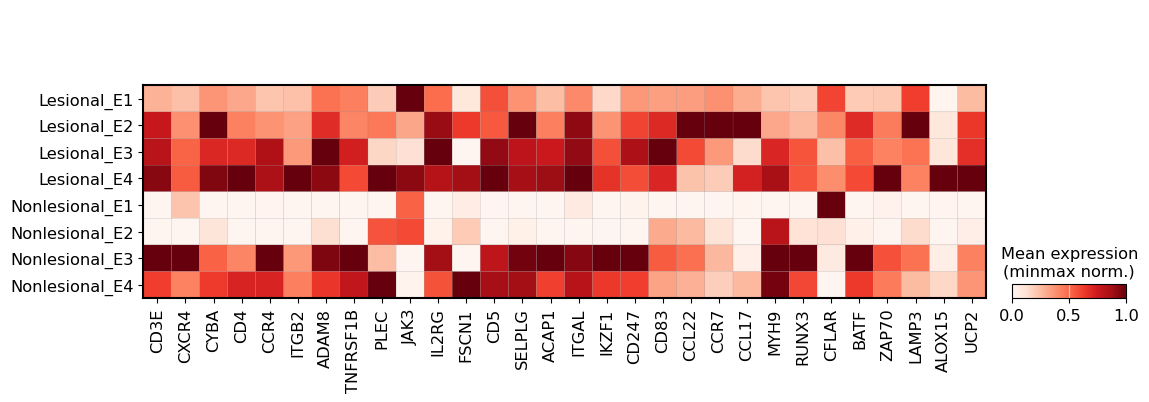

In [7]:
sc.pl.matrixplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation2",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds",
                categories_order=sorted(list(adata_iii.obs["validation2"].unique())),
                 colorbar_title="Mean expression\n(minmax norm.)"
                )
# sc.pl.dotplot(adata_iii, 
#               gene_programme200[:30],
#               groupby="validation2",
#               dendrogram=True, 
#                 standard_scale="var",
#                 cmap="Reds")

# reviewer fig

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

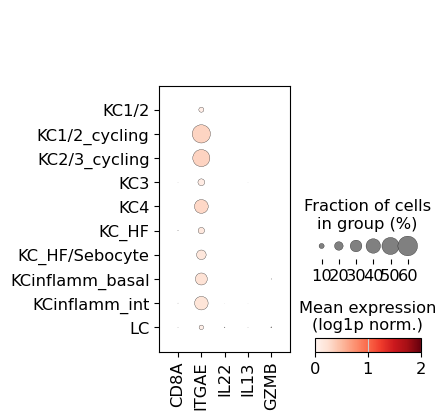

In [8]:
GENES = ["CD8A", 'ITGAE', 
         'IL22', 'IL13',
   'GZMB',]
sc.pl.dotplot(adata_iii[(adata_iii.obs["final_annotation_lvl3"].str.startswith("KC"))|
                        (adata_iii.obs["final_annotation_lvl3"].str.startswith("LC"))]
                        
                        , 
              GENES,
              groupby="final_annotation_lvl3",
              dendrogram=False, 
              #  standard_scale="var",
                cmap="Reds",
              vmax=2,
              colorbar_title="Mean expression\n(log1p norm.)",
              save="reviewer_fig_spillover.pdf"
             
             )

In [10]:
1

1